In [13]:
from contextlib import redirect_stdout, redirect_stderr
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import logging
import os
import numpy as np
import sys


In [14]:
# Крок 1: Задаємо моделі для експерименту
# Можна використовувати v8 (стандарт), v9 або v11 (найновіші)
models_to_compare = [
    '../.pts/yolo26n-seg.pt', # YOLOv26 Nano
    '../.pts/yolo26s-seg.pt', # YOLOv26 Small
    '../.pts/yolo11n-seg.pt', # YOLOv11 Nano
    '../.pts/yolo11s-seg.pt',
    '../.pts/FastSAM-s.pt',
]

metrics_results = {}

In [42]:
models_name = [
    "yolo26n\n  6m",
    "yolo26s\n  22m",
    "yolo11n\n  6m",
    "yolo11s\n  20m",
    "FastSAM-s\n  24m",
]

size_models = [
    6, 
    22, 
    6, 
    20, 
    24
]

In [43]:
# %%capture
# # ^^^ ЦЕ МАЄ БУТИ НАЙПЕРШИЙ РЯДОК У КЛІТИНЦІ!
# # 1. Вимикаємо глобальний вивід YOLO через змінні середовища
# os.environ['YOLO_VERBOSE'] = 'False'

# # 2. Глушимо системний логер бібліотеки
# logging.getLogger('ultralytics').setLevel(logging.WARNING)

# metrics_results = {}

# for model_name in models_to_compare:
#     model = YOLO(model_name)
#     results = model.train(
#         data="../sfx_data.yaml", 
#         epochs=100, 
#         imgsz=640,
#         workers=0, 
#         project="sfx_comparison",
#         name=f"train_{model_name.split('.')[0]}",
#         patience=20,
#         verbose=False
#     )
    
#     metrics_results[model_name] = {
#         'mAP50-95 (Mask)': results.seg.map,    
#         'mAP50 (Mask)': results.seg.map50,      
#         'Inference (ms/img)': results.speed['inference'], 
#         'Parameters (M)': sum(p.numel() for p in model.model.parameters()) / 1e6 
#     }

In [44]:
# # Крок 4: Формування датафрейму для аналізу
# df_comparison = pd.DataFrame(metrics_results).T
# df_comparison.to_csv("df_comparison.csv")
# print("\n--- РЕЗУЛЬТАТИ ПОРІВНЯЛЬНОГО АНАЛІЗУ ---")
# print(df_comparison)

In [45]:
df_comparison = pd.read_csv("df_comparison_m.csv")
df_comparison

,Unnamed: 0,mAP50-95 (Mask),mAP50 (Mask),Inference (ms/img),Parameters (M)
0,../.pts/yolo26n-seg.pt,0.538357,0.762594,7.125980,3.053055
1,../.pts/yolo26s-seg.pt,0.586155,0.809631,10.786942,11.434463
2,../.pts/yolo11n-seg.pt,0.561118,0.814623,2.425342,2.842803
3,../.pts/yolo11s-seg.pt,0.506498,0.763309,6.631986,10.082675
4,../.pts/FastSAM-s.pt,0.467032,0.691023,5.032592,11.790483


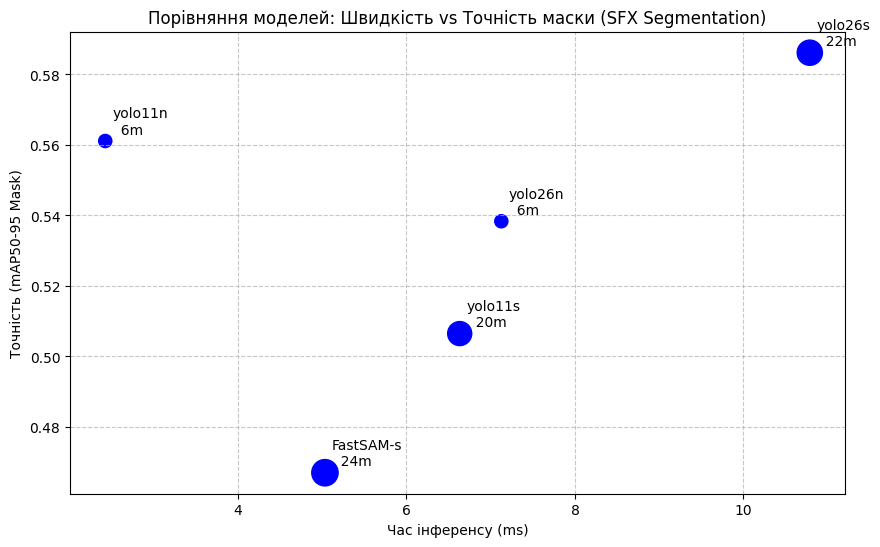

In [46]:
# Крок 5: Візуалізація (Точність vs Швидкість)
plt.figure(figsize=(10, 6))
plt.scatter(df_comparison['Inference (ms/img)'], df_comparison['mAP50-95 (Mask)'], color='blue', s=np.array(size_models)*15)

# Підписи точок (ВИПРАВЛЕНО)
for model_name in df_comparison.index:
    x_val = df_comparison['Inference (ms/img)'][model_name]
    y_val = df_comparison['mAP50-95 (Mask)'][model_name]
    
    plt.annotate(models_name[model_name], (x_val, y_val), 
                 xytext=(5, 5), textcoords='offset points')

plt.title('Порівняння моделей: Швидкість vs Точність маски (SFX Segmentation)')
plt.xlabel('Час інференсу (ms)')
plt.ylabel('Точність (mAP50-95 Mask)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
type(df_comparison.index[0])

int